<a href="https://colab.research.google.com/drive/1km3oHIIAs6i6zT5tTWxzlfnfEwAOcGuT?usp=sharing" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dados mensais de uma posição

Será mostrado como extrair dados mensais para um ponto.

Informações sobre o asset **BR-DWGD mensal** no GEE [aqui](https://code.earthengine.google.com/?asset=projects/ee-alexandrexavier/assets/BR-DWGD_Monthly)

In [1]:
import xarray as xr
import numpy as np
import plotly.express as px
import ee
import pandas as pd

In [2]:
ee.Authenticate()

True

In [4]:
ee.Initialize(project='ee-alexandrexavier')
print(ee.String('Hello from the Earth Engine servers!').getInfo())

Hello from the Earth Engine servers!


In [5]:
def parameters(var_name):
    if var_name == 'pr':
        var_set = {'offset': 750, 'scale': 0.022888, 'var_name': 'PR', 'var_unit': 'mm', 'vis_min':0, 'vis_max':200}

    elif var_name == 'ET':
        var_set = {'offset': -0.0511811, 'scale': 0.05118110, 'var_name': 'ET', 'var_unit': 'mm', 'vis_min':0, 'vis_max':6}

    elif var_name == 'RH':
        var_set = {'offset': -0.393701, 'scale': 0.39370079, 'var_name': 'RH', 'var_unit': '%', 'vis_min':40, 'vis_max':100}

    elif var_name == 'u2':
        var_set = {'offset': -0.059055, 'scale': 0.05905512, 'var_name': 'U2', 'var_unit': 'm/s', 'vis_min':0, 'vis_max':4}

    elif var_name == 'Rs':
        var_set = {'offset': -0.057087, 'scale': 0.15708661, 'var_name': 'RS', 'var_unit': 'MJ/m2', 'vis_min':0, 'vis_max':30}

    else: # TMAX or TMIN
        var_set = {'offset': 15, 'scale': 0.00106815, 'var_name': 'TMAX', 'var_unit': 'C', 'vis_min':10, 'vis_max':37}

  # set vizualization
    if var_set['var_name'] == 'PR':
        var_set['color_pal'] = ['#ffffcc', '#a1dab4', '#41b6c4', '#2c7fb8', '#253494']
    else:
        var_set['color_pal'] = ['040274', '040281', '0502a3', '0502b8', '0502ce', '0502e6', '0602ff', '235cb1', '307ef3', '269db1',
                                '30c8e2', '32d3ef','3be285', '3ff38f', '86e26f', '3ae237', 'b5e22e', 'd6e21f','fff705', 'ffd611',
                                'ffb613', 'ff8b13', 'ff6e08', 'ff500d', 'ff0000', 'de0101', 'c21301', 'a71001', '911003']

    return var_set

In [6]:
# funcao para reescalonamento e plotagem
def get_data(var_name, point, start_date, end_date):
    def scaleBand(image):
        scaledImage = image.multiply(var_set['scale']).add(var_set['offset'])

        return scaledImage.copyProperties(image, image.propertyNames())

    var_set = parameters(var_name)
    var = ee.ImageCollection('projects/ee-alexandrexavier/assets/BR-DWGD_Monthly') \
                        .filterDate(start_date, end_date) \
                        .select(var_name) \
                        .map(scaleBand)
    dados = var.getRegion(point, scale=10000).getInfo()
    df = pd.DataFrame(dados[1:], columns=['id', 'lon', 'lat', 'time', 'value'])
    df.rename(columns={})
    df['Data'] = pd.to_datetime(df['id'].str[-8:]).values
    df['var_name'] = var_name

    return df[['value', 'var_name', 'Data']]

## Definição de período e posição

In [7]:
# período
start_date, end_date = '1961-01-01','2026-01-01'
# coordenada do ponto de interesse [lon, lat]
lon_lat = [-52.4, -29.3]
point = {'type': 'Point', 'coordinates': lon_lat}

## Dados de Tmax, Tmin e Rs

In [8]:
df_tmax = get_data('Tmax', point, start_date, end_date)
df_tmin = get_data('Tmin', point, start_date, end_date)
df_rs = get_data('Rs', point, start_date, end_date)

In [9]:
df = pd.concat([df_tmax, df_tmin, df_rs], axis=0)#.reset_index(inplace=True)
df.reset_index(inplace=True)

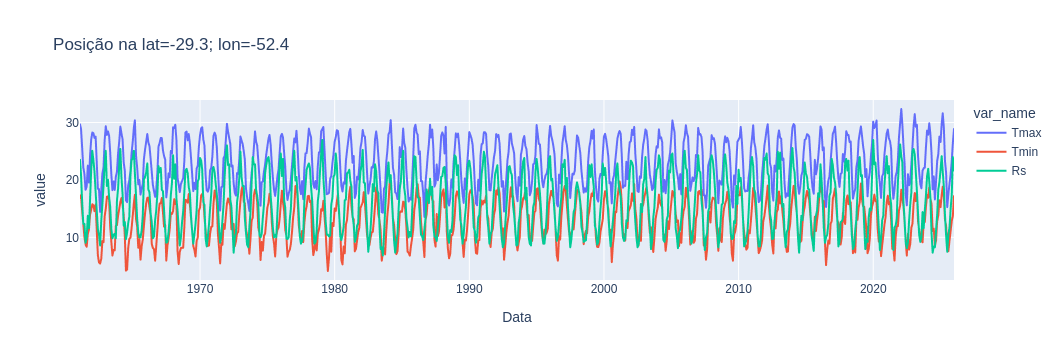

In [10]:
fig = px.line(df, x='Data', y='value', color='var_name',
              title=f"Posição na lat={lon_lat[1]}; lon={lon_lat[0]}")
fig.update_traces(hovertemplate="Data: %{x} <br> value: %{y:.1f}")
fig.show()

## Dados de precipitação acumulada

In [11]:
df_pr = get_data('pr', point, start_date, end_date)

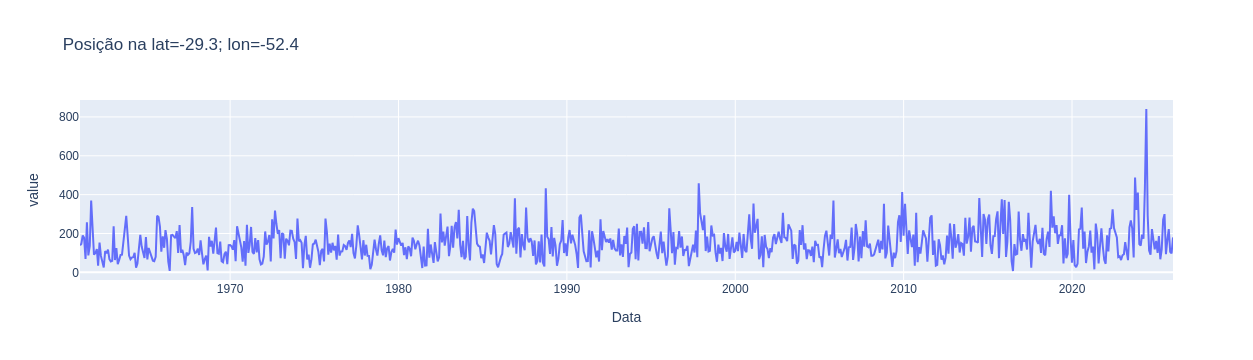

In [12]:
fig = px.line(df_pr, x='Data', y='value',
              title=f"Posição na lat={lon_lat[1]}; lon={lon_lat[0]}")
fig.update_traces(hovertemplate="Data: %{x} <br> prec. acumulada: %{y:.1f} mm ")
fig.show()

In [13]:
df_y = df_pr.resample('YE', on='Data').sum()['value']



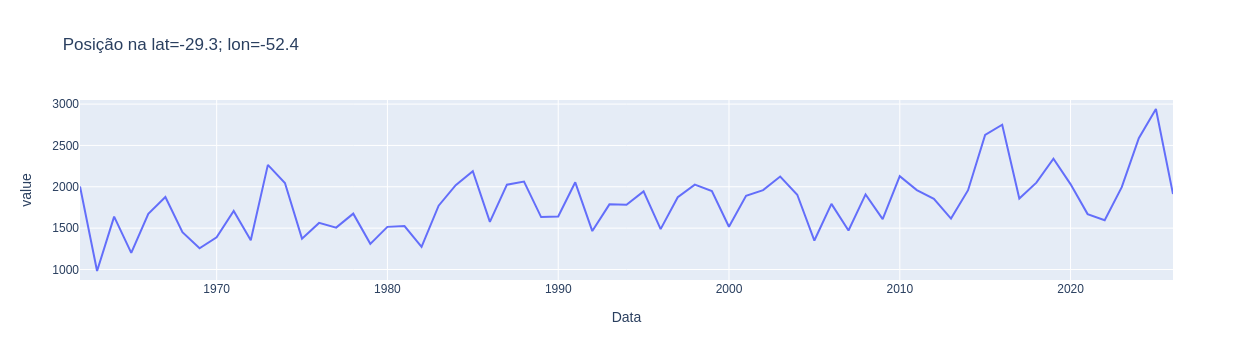

In [14]:
fig = px.line(df_y, x=df_y.index, y='value',
              title=f"Posição na lat={lon_lat[1]}; lon={lon_lat[0]}")
fig.update_traces(hovertemplate="Data: %{x} <br> prec. acumulada: %{y:.1f} mm ")
fig.show()